In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_score
from itertools import product
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Load CSV files
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X = train_data.drop('Label', axis=1)  # Replace 'target_column_name' with the actual target column
y = train_data['Label']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    TPR = TP / (TP + FN)  # true positive rate
    TNR = TN / (TN + FP)  # true negative rate
    FPR = FP / (FP + TN)  # false positive rate
    FNR = FN / (FN + TP)  # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

# Define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            'hidden_layer_sizes': [(20,), (50,)],
            'activation': ['tanh', 'relu'],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Lists to store ROC data
roc_fpr = []
roc_tpr = []
roc_auc = []

# Loop over models
for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=500)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=500)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)  # Add this line for precision
    accuracy = accuracy_score(y_test, preds)
    
    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')
    
    # Append ROC data to lists
    roc_fpr.append(fpr)
    roc_tpr.append(tpr)
    roc_auc.append(roc_score)


In [ ]:
import numpy as np

# Plot ROC curves
# plt.figure(figsize=(10, 6))
plt.figure(figsize=(5, 3))
for i, name in enumerate(models.keys()):
    plt.plot(roc_fpr[i], roc_tpr[i], label=f'{name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Home-C_sim', fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\All_Models_ROC_sim.png',bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_score
from itertools import product
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Load CSV files
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_real_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X = train_data.drop('Label', axis=1)  # Replace 'target_column_name' with the actual target column
y = train_data['Label']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    TPR = TP / (TP + FN)  # true positive rate
    TNR = TN / (TN + FP)  # true negative rate
    FPR = FP / (FP + TN)  # false positive rate
    FNR = FN / (FN + TP)  # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

# Define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            'hidden_layer_sizes': [(20,), (50,)],
            'activation': ['tanh', 'relu'],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Lists to store ROC data
roc_fpr = []
roc_tpr = []
roc_auc = []

# Loop over models
for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=500)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=500)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)  # Add this line for precision
    accuracy = accuracy_score(y_test, preds)
    
    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')
    
    # Append ROC data to lists
    roc_fpr.append(fpr)
    roc_tpr.append(tpr)
    roc_auc.append(roc_score)

# Plot ROC curves
plt.figure(figsize=(5, 3))
for i, name in enumerate(models.keys()):
    plt.plot(roc_fpr[i], roc_tpr[i], label=f'{name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Home-C_real', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\All_Models_ROC_real.png',bbox_inches='tight')
plt.show()


In [ ]:

# Plot ROC curves
plt.figure(figsize=(5, 3))
for i, name in enumerate(models.keys()):
    plt.plot(roc_fpr[i], roc_tpr[i], label=f'{name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Home-C_real', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\All_Models_ROC_real.png',bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_score
from itertools import product
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Load CSV files
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X = train_data.drop('Label', axis=1)  # Replace 'target_column_name' with the actual target column
y = train_data['Label']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    TPR = TP / (TP + FN)  # true positive rate
    TNR = TN / (TN + FP)  # true negative rate
    FPR = FP / (FP + TN)  # false positive rate
    FNR = FN / (FN + TP)  # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

# Define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            'hidden_layer_sizes': [(20,), (50,)],
            'activation': ['tanh', 'relu'],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Lists to store ROC data
roc_fpr = []
roc_tpr = []
roc_auc = []

# Loop over models
for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=1000)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=1000)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)  # Add this line for precision
    accuracy = accuracy_score(y_test, preds)
    
    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')
    
    # Append ROC data to lists
    roc_fpr.append(fpr)
    roc_tpr.append(tpr)
    roc_auc.append(roc_score)


In [ ]:
# Plot ROC curves
plt.figure(figsize=(5, 3))
for i, name in enumerate(models.keys()):
    plt.plot(roc_fpr[i], roc_tpr[i], label=f'{name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Home-A_sim', fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\All_Models_ROC_sim.png',bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_score
from itertools import product
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Load CSV files
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_real_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X = train_data.drop('Label', axis=1)  # Replace 'target_column_name' with the actual target column
y = train_data['Label']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    TPR = TP / (TP + FN)  # true positive rate
    TNR = TN / (TN + FP)  # true negative rate
    FPR = FP / (FP + TN)  # false positive rate
    FNR = FN / (FN + TP)  # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

# Define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            'hidden_layer_sizes': [(20,), (50,)],
            'activation': ['tanh', 'relu'],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Lists to store ROC data
roc_fpr = []
roc_tpr = []
roc_auc = []

Metrics for XGBoost with best params:
Rates: {'TPR': 0.9131330977620731, 'TNR': 0.9872492836676218, 'FPR': 0.012750716332378223, 'FNR': 0.08686690223792698} - F1 Score: 0.9481005885500268 - Precision: 0.9858528055952949 - Accuracy: 0.950697066511763 - Confusion Matrix:
 [[6891   89]
 [ 590 6202]]

ROC Score: 0.9875801655242474
Metrics for Random Forest with best params:
Rates: {'TPR': 0.8448174322732627, 'TNR': 0.9921203438395415, 'FPR': 0.007879656160458453, 'FNR': 0.15518256772673733} - F1 Score: 0.9118792212951927 - Precision: 0.9905057828413603 - Accuracy: 0.9194742956723787 - Confusion Matrix:
 [[6925   55]
 [1054 5738]]

ROC Score: 0.9660242561618084
Metrics for MLP with best params:


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


Rates: {'TPR': 0.910924617196702, 'TNR': 0.9305157593123209, 'FPR': 0.06948424068767908, 'FNR': 0.08907538280329799} - F1 Score: 0.9190433749257279 - Precision: 0.9273081534772182 - Accuracy: 0.9208539064769097 - Confusion Matrix:
 [[6495  485]
 [ 605 6187]]

ROC Score: 0.5


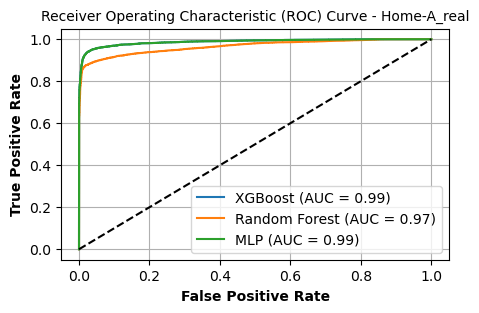

In [3]:
# Loop over models
for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=500)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params
# Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=500)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)  # Add this line for precision
    accuracy = accuracy_score(y_test, preds)
    
    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')
    
    # Append ROC data to lists
    roc_fpr.append(fpr)
    roc_tpr.append(tpr)
    roc_auc.append(roc_score)

# Plot ROC curves
plt.figure(figsize=(5, 3))
for i, name in enumerate(models.keys()):
    plt.plot(roc_fpr[i], roc_tpr[i], label=f'{name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Home-A_real', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A\All_Models_ROC_real.png',bbox_inches='tight')
plt.show()


Metrics for XGBoost with best params:
Rates: {'TPR': 0.9281193490054249, 'TNR': 0.9940179461615155, 'FPR': 0.005982053838484547, 'FNR': 0.07188065099457505} - F1 Score: 0.959569992989016 - Precision: 0.9932268988872762 - Accuracy: 0.9619975104342096 - Confusion Matrix:
 [[6979   42]
 [ 477 6159]]

ROC Score: 0.9878162700394468
Metrics for Random Forest with best params:
Rates: {'TPR': 0.875075346594334, 'TNR': 0.9981484119071358, 'FPR': 0.0018515880928642644, 'FNR': 0.12492465340566607} - F1 Score: 0.9324020552344252 - Precision: 0.997766323024055 - Accuracy: 0.9383466354250567 - Confusion Matrix:
 [[7008   13]
 [ 829 5807]]

ROC Score: 0.9774902666494618
Metrics for MLP with best params:


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


Rates: {'TPR': 0.9196805304400241, 'TNR': 0.9528557185586098, 'FPR': 0.047144281441390115, 'FNR': 0.08031946955997589} - F1 Score: 0.93389441469013 - Precision: 0.948554553932235 - Accuracy: 0.9367357399135974 - Confusion Matrix:
 [[6690  331]
 [ 533 6103]]

ROC Score: 0.5


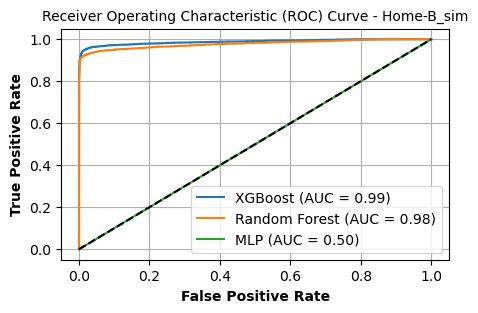

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_score
from itertools import product
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Load CSV files
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_B_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_B_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)
###################################################
import pandas as pd

# Assuming df is your DataFrame
X = df.values  # This converts the DataFrame to a NumPy array, removing feature names

##################################################

# Separate features and labels
X = train_data.drop('Label', axis=1)  # Replace 'target_column_name' with the actual target column
y = train_data['Label']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    TPR = TP / (TP + FN)  # true positive rate
    TNR = TN / (TN + FP)  # true negative rate
    FPR = FP / (FP + TN)  # false positive rate
    FNR = FN / (FN + TP)  # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

# Define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            'hidden_layer_sizes': [(20,), (50,)],
            'activation': ['tanh', 'relu'],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Lists to store ROC data
roc_fpr = []
roc_tpr = []
roc_auc = []

# Loop over models
for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=500)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=500)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)  # Add this line for precision
    accuracy = accuracy_score(y_test, preds)
    
    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')
    
    # Append ROC data to lists
    roc_fpr.append(fpr)
    roc_tpr.append(tpr)
    roc_auc.append(roc_score)

# Plot ROC curves
plt.figure(figsize=(5, 3))
for i, name in enumerate(models.keys()):
    plt.plot(roc_fpr[i], roc_tpr[i], label=f'{name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Home-B_sim', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\All_Models_ROC_sim.png',bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_score
from itertools import product
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Load CSV files
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_B_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_B_real_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X = train_data.drop('Label', axis=1)  # Replace 'target_column_name' with the actual target column
y = train_data['Label']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    TPR = TP / (TP + FN)  # true positive rate
    TNR = TN / (TN + FP)  # true negative rate
    FPR = FP / (FP + TN)  # false positive rate
    FNR = FN / (FN + TP)  # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

# Define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            'hidden_layer_sizes': [(16,), (32,)],
            'activation': ['tanh', 'relu'],
 #           'batch_size': [50, 100],
            'batch_size': [32, 64],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Lists to store ROC data
roc_fpr = []
roc_tpr = []
roc_auc = []

# Loop over models
for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=500)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=500)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)  # Add this line for precision
    accuracy = accuracy_score(y_test, preds)
    
    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')
    
    # Append ROC data to lists
    roc_fpr.append(fpr)
    roc_tpr.append(tpr)
    roc_auc.append(roc_score)

# Plot ROC curves
plt.figure(figsize=(5, 3))
for i, name in enumerate(models.keys()):
    plt.plot(roc_fpr[i], roc_tpr[i], label=f'{name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate, fontsize=10', fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Home-B_real', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\All_Models_ROC_real.png',bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_score
from itertools import product
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Load CSV files
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_real_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X = train_data.drop('Label', axis=1)  # Replace 'target_column_name' with the actual target column
y = train_data['Label']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    TPR = TP / (TP + FN)  # true positive rate
    TNR = TN / (TN + FP)  # true negative rate
    FPR = FP / (FP + TN)  # false positive rate
    FNR = FN / (FN + TP)  # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

# Define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            'hidden_layer_sizes': [(20,), (50,)],
            'activation': ['tanh', 'relu'],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Lists to store ROC data
roc_fpr = []
roc_tpr = []
roc_auc = []

# Loop over models
for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=500)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=500)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)  # Add this line for precision
    accuracy = accuracy_score(y_test, preds)
    
    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')
    
    # Append ROC data to lists
    roc_fpr.append(fpr)
    roc_tpr.append(tpr)
    roc_auc.append(roc_score)

# Plot ROC curves
plt.figure(figsize=(5, 3))
for i, name in enumerate(models.keys()):
    plt.plot(roc_fpr[i], roc_tpr[i], label=f'{name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Home-C_real', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\All_Models_ROC_real.png',bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_auc_score, roc_curve, precision_score
from itertools import product
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Load CSV files
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X = train_data.drop('Label', axis=1)  # Replace 'target_column_name' with the actual target column
y = train_data['Label']

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP = conf_matrix[0]
    FN, TP = conf_matrix[1]

    TPR = TP / (TP + FN)  # true positive rate
    TNR = TN / (TN + FP)  # true negative rate
    FPR = FP / (FP + TN)  # false positive rate
    FNR = FN / (FN + TP)  # false negative rate

    return {'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR}

# Define the models and hyperparameters
models = {
    'XGBoost': {
        'model': XGBClassifier,
        'params': {
            'learning_rate': [0.01, 0.1],
            'n_estimators': [50, 100]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10]
        }
    },
    'MLP': {
        'model': MLPClassifier,
        'params': {
            'hidden_layer_sizes': [(20,), (50,)],
            'activation': ['tanh', 'relu'],
            'batch_size': [50, 100],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# Lists to store ROC data
roc_fpr = []
roc_tpr = []
roc_auc = []

# Loop over models
for name, model_info in models.items():
    param_values = [v for v in model_info['params'].values()]
    best_f1 = -1
    best_params = None
    for p in product(*param_values):
        params = dict(zip(model_info['params'].keys(), p))
        if name == 'MLP':
            model = model_info['model'](**params, max_iter=500)
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
        else:
            model = model_info['model'](**params)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_params = params

    models[name]['best_params'] = best_params

    # Compute metrics for each model with best params
    print(f'Metrics for {name} with best params:')
    if name == 'MLP':
        model = model_info['model'](**best_params, max_iter=500)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model = model_info['model'](**best_params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, preds)
    rates = compute_rates(conf_matrix)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)  # Add this line for precision
    accuracy = accuracy_score(y_test, preds)
    
    # Compute ROC and AUC
    roc_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

    print(f'Rates: {rates} - F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy} - Confusion Matrix:\n {conf_matrix}\n')
    print(f'ROC Score: {roc_score}')
    
    # Append ROC data to lists
    roc_fpr.append(fpr)
    roc_tpr.append(tpr)
    roc_auc.append(roc_score)

# Plot ROC curves
plt.figure(figsize=(5, 3))
for i, name in enumerate(models.keys()):
    plt.plot(roc_fpr[i], roc_tpr[i], label=f'{name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate', fontsize=10, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=10, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve - Home-C_sim', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C\All_Models_ROC_sim.png',bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from itertools import product

# Load the dataset
df = pd.read_csv('C:\Project\Journal\dataset\home_A_synthetic_real_combined_shuffled.csv')
X = df.drop('Label', axis=1)
y = df['Label']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the MLP model and its hyperparameters
mlp_params = {
    'hidden_layer_sizes': [(20,), (50,)],
    'activation': ['tanh', 'relu'],
    'batch_size': [50, 100],
    'learning_rate_init': [0.001, 0.01]
}

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_auc = -1
best_params = None

# Grid search for best hyperparameters for MLP
for p in product(*mlp_params.values()):
    params = dict(zip(mlp_params.keys(), p))
    model = MLPClassifier(**params, max_iter=500)
    model.fit(X_train_scaled, y_train)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, preds)
    
    if auc > best_auc:
        best_auc = auc
        best_params = params

# Create the best MLP model with the best hyperparameters
best_mlp_model = MLPClassifier(**best_params, max_iter=500)
best_mlp_model.fit(X_train_scaled, y_train)
preds_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

# Compute and print the AUC for the best MLP model
mlp_auc = roc_auc_score(y_test, preds_mlp)
print(f'Best MLP AUC: {mlp_auc}')


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from itertools import product

# Load the dataset
df = pd.read_csv('C:\Project\Journal\dataset\home_A_synthetic_sim_combined_shuffled.csv')
X = df.drop('Label', axis=1)
y = df['Label']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the MLP model and its hyperparameters
mlp_params = {
    'hidden_layer_sizes': [(20,), (50,)],
    'activation': ['tanh', 'relu'],
    'batch_size': [50, 100],
    'learning_rate_init': [0.001, 0.01]
}

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_auc = -1
best_params = None

# Grid search for best hyperparameters for MLP
for p in product(*mlp_params.values()):
    params = dict(zip(mlp_params.keys(), p))
    model = MLPClassifier(**params, max_iter=500)
    model.fit(X_train_scaled, y_train)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, preds)
    
    if auc > best_auc:
        best_auc = auc
        best_params = params

# Create the best MLP model with the best hyperparameters
best_mlp_model = MLPClassifier(**best_params, max_iter=500)
best_mlp_model.fit(X_train_scaled, y_train)
preds_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

# Compute and print the AUC for the best MLP model
mlp_auc = roc_auc_score(y_test, preds_mlp)
print(f'Best MLP AUC: {mlp_auc}')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from itertools import product

# Load the dataset
df = pd.read_csv('C:\Project\Journal\dataset\home_B_synthetic_sim_combined_shuffled.csv')
X = df.drop('Label', axis=1)
y = df['Label']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the MLP model and its hyperparameters
mlp_params = {
    'hidden_layer_sizes': [(20,), (50,)],
    'activation': ['tanh', 'relu'],
    'batch_size': [50, 100],
    'learning_rate_init': [0.001, 0.01]
}

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_auc = -1
best_params = None

# Grid search for best hyperparameters for MLP
for p in product(*mlp_params.values()):
    params = dict(zip(mlp_params.keys(), p))
    model = MLPClassifier(**params, max_iter=500)
    model.fit(X_train_scaled, y_train)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, preds)
    
    if auc > best_auc:
        best_auc = auc
        best_params = params

# Create the best MLP model with the best hyperparameters
best_mlp_model = MLPClassifier(**best_params, max_iter=500)
best_mlp_model.fit(X_train_scaled, y_train)
preds_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

# Compute and print the AUC for the best MLP model
mlp_auc = roc_auc_score(y_test, preds_mlp)
print(f'Best MLP AUC: {mlp_auc}')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from itertools import product

# Load the dataset
df = pd.read_csv('C:\Project\Journal\dataset\home_B_synthetic_real_combined_shuffled.csv')
X = df.drop('Label', axis=1)
y = df['Label']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the MLP model and its hyperparameters
mlp_params = {
    'hidden_layer_sizes': [(20,), (50,)],
    'activation': ['tanh', 'relu'],
    'batch_size': [50, 100],
    'learning_rate_init': [0.001, 0.01]
}

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_auc = -1
best_params = None

# Grid search for best hyperparameters for MLP
for p in product(*mlp_params.values()):
    params = dict(zip(mlp_params.keys(), p))
    model = MLPClassifier(**params, max_iter=500)
    model.fit(X_train_scaled, y_train)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, preds)
    
    if auc > best_auc:
        best_auc = auc
        best_params = params

# Create the best MLP model with the best hyperparameters
best_mlp_model = MLPClassifier(**best_params, max_iter=500)
best_mlp_model.fit(X_train_scaled, y_train)
preds_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

# Compute and print the AUC for the best MLP model
mlp_auc = roc_auc_score(y_test, preds_mlp)
print(f'Best MLP AUC: {mlp_auc}')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from itertools import product

# Load the dataset
df = pd.read_csv('C:\Project\Journal\dataset\home_C_synthetic_sim_combined_shuffled.csv')
X = df.drop('Label', axis=1)
y = df['Label']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the MLP model and its hyperparameters
mlp_params = {
    'hidden_layer_sizes': [(20,), (50,)],
    'activation': ['tanh', 'relu'],
    'batch_size': [50, 100],
    'learning_rate_init': [0.001, 0.01]
}

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_auc = -1
best_params = None

# Grid search for best hyperparameters for MLP
for p in product(*mlp_params.values()):
    params = dict(zip(mlp_params.keys(), p))
    model = MLPClassifier(**params, max_iter=500)
    model.fit(X_train_scaled, y_train)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, preds)
    
    if auc > best_auc:
        best_auc = auc
        best_params = params

# Create the best MLP model with the best hyperparameters
best_mlp_model = MLPClassifier(**best_params, max_iter=500)
best_mlp_model.fit(X_train_scaled, y_train)
preds_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

# Compute and print the AUC for the best MLP model
mlp_auc = roc_auc_score(y_test, preds_mlp)
print(f'Best MLP AUC: {mlp_auc}')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from itertools import product

# Load the dataset
df = pd.read_csv('C:\Project\Journal\dataset\home_C_synthetic_real_combined_shuffled.csv')
X = df.drop('Label', axis=1)
y = df['Label']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the MLP model and its hyperparameters
mlp_params = {
    'hidden_layer_sizes': [(20,), (50,)],
    'activation': ['tanh', 'relu'],
    'batch_size': [50, 100],
    'learning_rate_init': [0.001, 0.01]
}

# Normalize data for MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_auc = -1
best_params = None

# Grid search for best hyperparameters for MLP
for p in product(*mlp_params.values()):
    params = dict(zip(mlp_params.keys(), p))
    model = MLPClassifier(**params, max_iter=500)
    model.fit(X_train_scaled, y_train)
    preds = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, preds)
    
    if auc > best_auc:
        best_auc = auc
        best_params = params

# Create the best MLP model with the best hyperparameters
best_mlp_model = MLPClassifier(**best_params, max_iter=500)
best_mlp_model.fit(X_train_scaled, y_train)
preds_mlp = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

# Compute and print the AUC for the best MLP model
mlp_auc = roc_auc_score(y_test, preds_mlp)
print(f'Best MLP AUC: {mlp_auc}')

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from itertools import product

# Load CSV files
# train_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_synthetic_train.csv"
# test_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X_train, X_test, y_train, y_test = train_test_split(
    train_data.drop('Label', axis=1), train_data['Label'], test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM model and hyperparameters
svm_model = SVC()
parameters = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}

# Grid Search for hyperparameter tuning
grid_search = GridSearchCV(svm_model, parameters, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

# Best model after grid search
best_svm_model = grid_search.best_estimator_

# Predictions and metrics
preds = best_svm_model.predict(X_test_scaled)
f1 = f1_score(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    return {
        'TPR': TP / (TP + FN),
        'TNR': TN / (TN + FP),
        'FPR': FP / (FP + TN),
        'FNR': FN / (FN + TP)
    }

rates = compute_rates(conf_matrix)

# Output the results
print(f'Metrics for SVM with best params:')
print(f'F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}\n')
print(f'Rates: {rates}\n')

# ROC and AUC
roc_score = roc_auc_score(y_test, best_svm_model.decision_function(X_test_scaled))
fpr, tpr, _ = roc_curve(y_test, best_svm_model.decision_function(X_test_scaled))

# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Metrics for SVM with best params:
F1 Score: 0.8920984129649846 - Precision: 0.9470493849170976 - Accuracy: 0.9034923019151333
Confusion Matrix:
[[6718  297]
 [ 988 5312]]

Rates: {'TPR': 0.8431746031746031, 'TNR': 0.9576621525302922, 'FPR': 0.04233784746970777, 'FNR': 0.1568253968253968}



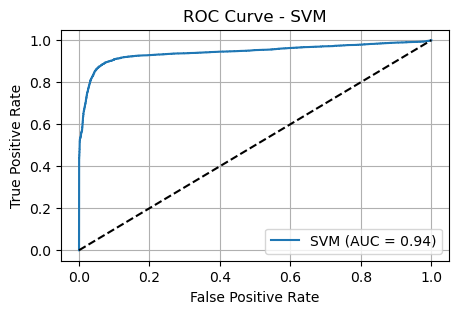

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# Load CSV files
# train_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_synthetic_train.csv"
# test_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Use a sample of the data if the dataset is large
# train_data = train_data.sample(frac=0.1, random_state=42)

# Separate features and labels
X_train, X_test, y_train, y_test = train_test_split(
    train_data.drop('Label', axis=1), train_data['Label'], test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM model and reduced hyperparameters
svm_model = SVC()
parameters = {'C': [1], 'kernel': ['rbf']}  # Example: reduced to a single parameter set

# Grid Search with reduced CV and parallel processing
grid_search = GridSearchCV(svm_model, parameters, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best model after grid search
best_svm_model = grid_search.best_estimator_

# Predictions and metrics
preds = best_svm_model.predict(X_test_scaled)
f1 = f1_score(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    return {
        'TPR': TP / (TP + FN),
        'TNR': TN / (TN + FP),
        'FPR': FP / (FP + TN),
        'FNR': FN / (FN + TP)
    }

rates = compute_rates(conf_matrix)

# Output the results
print(f'Metrics for SVM with best params:')
print(f'F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}\n')
print(f'Rates: {rates}\n')

# ROC and AUC
roc_score = roc_auc_score(y_test, best_svm_model.decision_function(X_test_scaled))
fpr, tpr, _ = roc_curve(y_test, best_svm_model.decision_function(X_test_scaled))
print(f'ROC Score: {roc_score}')

# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [3]:
print(f'ROC Score: {roc_score}')

ROC Score: 0.942976094310378


### LRC - Home A_sim

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Metrics for Logistic Regression:
F1 Score: 0.6845185600897941 - Precision: 0.7514522091181131 - Accuracy: 0.7142753412721464
Confusion Matrix:
[[5568 1412]
 [2523 4269]]

Rates: {'TPR': 0.6285335689045937, 'TNR': 0.7977077363896848, 'FPR': 0.2022922636103152, 'FNR': 0.37146643109540634}

ROC Score: 0.790138701860608


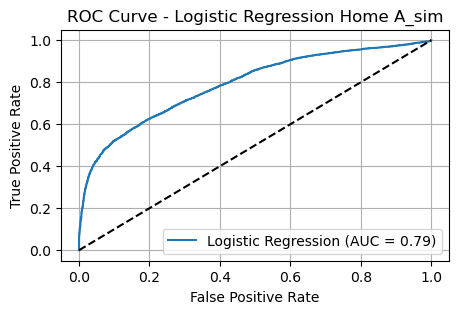

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load CSV files
# train_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_synthetic_train.csv"
# test_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X_train, X_test, y_train, y_test = train_test_split(
    train_data.drop('Label', axis=1), train_data['Label'], test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions and metrics
preds = lr_model.predict(X_test_scaled)
f1 = f1_score(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    return {
        'TPR': TP / (TP + FN),
        'TNR': TN / (TN + FP),
        'FPR': FP / (FP + TN),
        'FNR': FN / (FN + TP)
    }

rates = compute_rates(conf_matrix)

# Output the results
print(f'Metrics for Logistic Regression:')
print(f'F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}\n')
print(f'Rates: {rates}\n')

# ROC and AUC
roc_score = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
fpr, tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
print(f'ROC Score: {roc_score}')

# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression Home A_sim')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LR_ROC_sim.png', bbox_inches='tight')
plt.show()


### LR - Home A_real

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Metrics for Logistic Regression:
F1 Score: 0.6845185600897941 - Precision: 0.7514522091181131 - Accuracy: 0.7142753412721464
Confusion Matrix:
[[5568 1412]
 [2523 4269]]

Rates: {'TPR': 0.6285335689045937, 'TNR': 0.7977077363896848, 'FPR': 0.2022922636103152, 'FNR': 0.37146643109540634}

ROC Score: 0.790138701860608


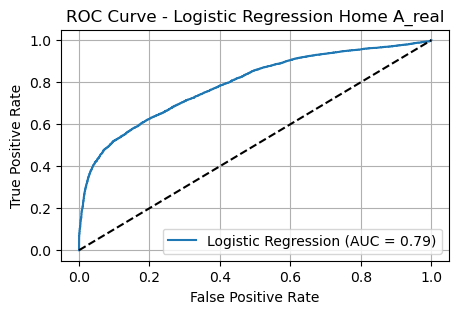

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load CSV files
# train_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_synthetic_train.csv"
# test_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_real_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X_train, X_test, y_train, y_test = train_test_split(
    train_data.drop('Label', axis=1), train_data['Label'], test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions and metrics
preds = lr_model.predict(X_test_scaled)
f1 = f1_score(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    return {
        'TPR': TP / (TP + FN),
        'TNR': TN / (TN + FP),
        'FPR': FP / (FP + TN),
        'FNR': FN / (FN + TP)
    }

rates = compute_rates(conf_matrix)

# Output the results
print(f'Metrics for Logistic Regression:')
print(f'F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}\n')
print(f'Rates: {rates}\n')

# ROC and AUC
roc_score = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
fpr, tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
print(f'ROC Score: {roc_score}')

# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression Home A_real')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_A_up\LR_ROC_real.png', bbox_inches='tight')
plt.show()


### LRC Home C

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Metrics for Logistic Regression:
F1 Score: 0.7888337044014386 - Precision: 0.8564522127184827 - Accuracy: 0.8147953435974465
Confusion Matrix:
[[6243  772]
 [1694 4606]]

Rates: {'TPR': 0.7311111111111112, 'TNR': 0.8899501069137562, 'FPR': 0.11004989308624376, 'FNR': 0.2688888888888889}

ROC Score: 0.8748046023826493


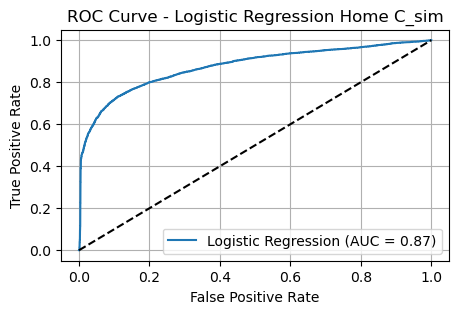

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load CSV files
# train_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_synthetic_train.csv"
# test_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_sim_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X_train, X_test, y_train, y_test = train_test_split(
    train_data.drop('Label', axis=1), train_data['Label'], test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions and metrics
preds = lr_model.predict(X_test_scaled)
f1 = f1_score(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    return {
        'TPR': TP / (TP + FN),
        'TNR': TN / (TN + FP),
        'FPR': FP / (FP + TN),
        'FNR': FN / (FN + TP)
    }

rates = compute_rates(conf_matrix)

# Output the results
print(f'Metrics for Logistic Regression:')
print(f'F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}\n')
print(f'Rates: {rates}\n')

# ROC and AUC
roc_score = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
fpr, tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
print(f'ROC Score: {roc_score}')

# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression Home C_sim')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LR_ROC_sim.png', bbox_inches='tight')
plt.show()

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Metrics for Logistic Regression:
F1 Score: 0.7888337044014386 - Precision: 0.8564522127184827 - Accuracy: 0.8147953435974465
Confusion Matrix:
[[6243  772]
 [1694 4606]]

Rates: {'TPR': 0.7311111111111112, 'TNR': 0.8899501069137562, 'FPR': 0.11004989308624376, 'FNR': 0.2688888888888889}

ROC Score: 0.8748046023826493


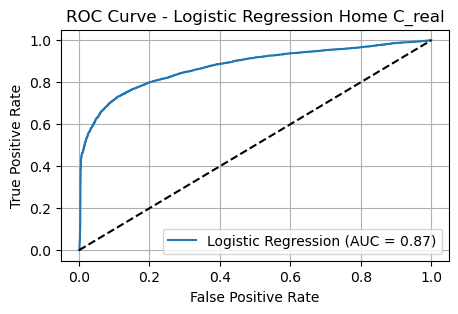

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load CSV files
# train_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_synthetic_train.csv"
# test_file_path = "/home/olufemiabiodu-a/My_Project/projects/Journal/dataset/psa_journal_home_A_sim_test.csv"
train_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_synthetic_train.csv"
test_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_C_real_test.csv"
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)

# Separate features and labels
X_train, X_test, y_train, y_test = train_test_split(
    train_data.drop('Label', axis=1), train_data['Label'], test_size=0.2, random_state=42
)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions and metrics
preds = lr_model.predict(X_test_scaled)
f1 = f1_score(y_test, preds)
precision = precision_score(y_test, preds)
accuracy = accuracy_score(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

# Function to compute TPR, TNR, FPR, FNR
def compute_rates(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    return {
        'TPR': TP / (TP + FN),
        'TNR': TN / (TN + FP),
        'FPR': FP / (FP + TN),
        'FNR': FN / (FN + TP)
    }

rates = compute_rates(conf_matrix)

# Output the results
print(f'Metrics for Logistic Regression:')
print(f'F1 Score: {f1} - Precision: {precision} - Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}\n')
print(f'Rates: {rates}\n')

# ROC and AUC
roc_score = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
fpr, tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
print(f'ROC Score: {roc_score}')

# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression Home C_real')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_C_up\LR_ROC_real.png', bbox_inches='tight')
plt.show()

